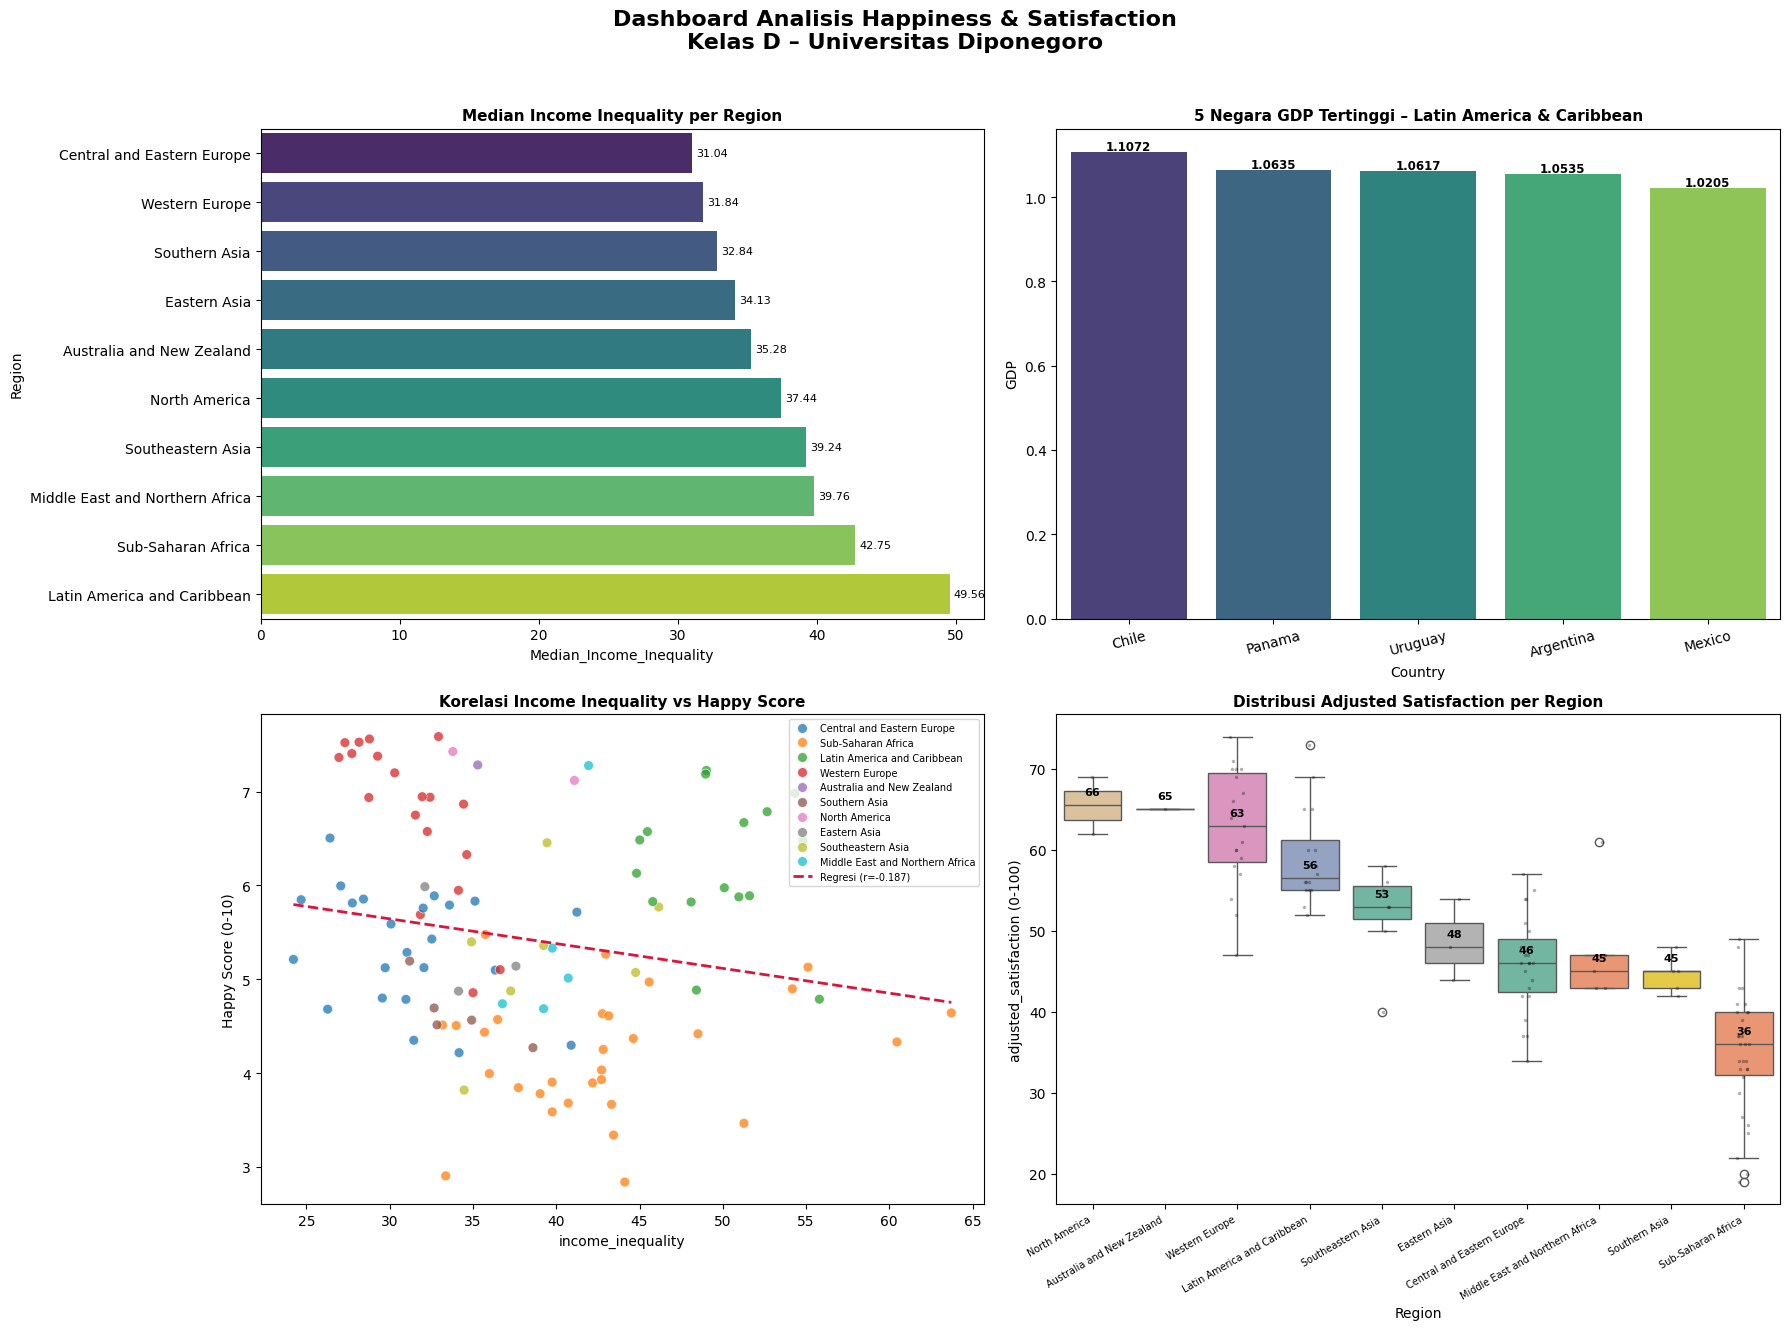

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ══════════════════════════════════════════════════════════════════
# 1. LOAD & PERSIAPAN DATA
# ══════════════════════════════════════════════════════════════════
df = pd.read_csv(
    '/content/Kelas D_Happiness and Satisfaction.csv',
    sep=';',
    decimal=','
)

df.columns = df.columns.str.strip()
df['Region'] = df['Region'].str.strip().str.strip("'")

# ══════════════════════════════════════════════════════════════════
# 2. KONFIGURASI DASHBOARD
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Dashboard Analisis Happiness & Satisfaction\nKelas D – Universitas Diponegoro',
             fontsize=16, fontweight='bold', y=1.02)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 1: Median Income Inequality per Region
# ─────────────────────────────────────────────────────────────────
ax1 = axes[0, 0]
median_ineq = df.groupby('Region')['income_inequality'].median().reset_index()
median_ineq.columns = ['Region', 'Median_Income_Inequality']
median_ineq = median_ineq.sort_values('Median_Income_Inequality', ascending=True)

sns.barplot(data=median_ineq, x='Median_Income_Inequality', y='Region', hue='Region',
            palette='viridis', legend=False, ax=ax1)

for p in ax1.patches:
    ax1.annotate(f'{p.get_width():.2f}', (p.get_width(), p.get_y() + p.get_height() / 2.),
                 ha='left', va='center', fontsize=8, xytext=(3, 0), textcoords='offset points')

ax1.set_title('Median Income Inequality per Region', fontsize=11, fontweight='bold')

# ─────────────────────────────────────────────────────────────────
# GRAFIK 2: 5 Negara GDP Tertinggi (Latin America & Caribbean)
# ─────────────────────────────────────────────────────────────────
ax2 = axes[0, 1]
lac_data = df[df['Region'] == 'Latin America and Caribbean'].copy()
lac_data['GDP'] = pd.to_numeric(lac_data['GDP'], errors='coerce')
top5_lac = lac_data.nlargest(5, 'GDP')

sns.barplot(x='Country', y='GDP', data=top5_lac, hue='Country', palette='viridis', legend=False, ax=ax2)
for idx, row in enumerate(top5_lac.itertuples()):
    ax2.text(idx, row.GDP + 0.005, f'{row.GDP:.4f}', ha='center', fontsize=8.5, fontweight='bold')

ax2.set_title('5 Negara GDP Tertinggi – Latin America & Caribbean', fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

# ─────────────────────────────────────────────────────────────────
# GRAFIK 3: Korelasi Income Inequality vs Happy Score
# ─────────────────────────────────────────────────────────────────
ax3 = axes[1, 0]
df_clean = df[['Country', 'Region', 'income_inequality', 'Happy Score (0-10)']].dropna()
x, y = df_clean['income_inequality'], df_clean['Happy Score (0-10)']
r, p_value = stats.pearsonr(x, y)

sns.scatterplot(data=df_clean, x='income_inequality', y='Happy Score (0-10)', hue='Region', ax=ax3, s=50, alpha=0.75)
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
ax3.plot(x_line, m * x_line + b, color='crimson', linewidth=2, linestyle='--', label=f'Regresi (r={r:.3f})')
ax3.set_title('Korelasi Income Inequality vs Happy Score', fontsize=11, fontweight='bold')
ax3.legend(fontsize=7, loc='upper right')

# ─────────────────────────────────────────────────────────────────
# GRAFIK 4: Distribusi Adjusted Satisfaction per Region
# ─────────────────────────────────────────────────────────────────
ax4 = axes[1, 1]
df['adjusted_satisfaction (0-100)'] = pd.to_numeric(df['adjusted_satisfaction (0-100)'], errors='coerce')
df4 = df.dropna(subset=['adjusted_satisfaction (0-100)', 'Region'])

region_order = df4.groupby('Region')['adjusted_satisfaction (0-100)'].median().sort_values(ascending=False).index.tolist()

sns.boxplot(data=df4, x='Region', y='adjusted_satisfaction (0-100)', order=region_order, hue='Region', palette='Set2', legend=False, ax=ax4)
sns.stripplot(data=df4, x='Region', y='adjusted_satisfaction (0-100)', order=region_order, color='black', size=2.5, alpha=0.3, ax=ax4)

# Anotasi Median (Angka di tengah box)
for i, region in enumerate(region_order):
    med = df4[df4['Region'] == region]['adjusted_satisfaction (0-100)'].median()
    ax4.text(i, med + 1.0, f'{med:.0f}', ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

ax4.set_xticks(range(len(region_order)))
ax4.set_xticklabels(region_order, rotation=30, ha='right', fontsize=7)
ax4.set_title('Distribusi Adjusted Satisfaction per Region', fontsize=11, fontweight='bold')

# ══════════════════════════════════════════════════════════════════
# 3. PENUTUP & SIMPAN
# ══════════════════════════════════════════════════════════════════
plt.tight_layout()
plt.savefig('dashboard_final.png', dpi=150, bbox_inches='tight')
plt.show()